# 36_conformal_pvalue_CHS — 분할 컨포멀 p-value: 최종 경보 구조의 점수를 정상 기준으로 보정된 p-value로

- 목적: 23의 최종 경보 구조(1차 차분 입력 Ridge-VAR + 1차 차분 진폭 피처 MCD)가 내는 **이상 점수**를, 정상 데이터만으로 만든 **분할 컨포멀(split conformal) p-value**로 바꾸고 그 보정이 실제로 성립하는지(명목 alpha 대 실측 정상 오경보율) 점검한다. 이상 데이터는 적합·calibration·선택 어디에도 쓰지 않는다.
- 입력: `data/raw`(형식 통일 신호, `ensemble_jsc.load_inputs`), `data/processed/11_window_features.parquet`(1초 윈도우·`fold`·`block`·`state`), 대조용 `results/23_model_ensemble_ridge_mcd_JSC/metrics.csv`·`cv_scores.csv`
- 출력: `figures/36_conformal_pvalue_CHS/`(그림 3개), `results/36_conformal_pvalue_CHS/`(CSV 9개). 새 모델이 아니라 23 점수 위의 보정 계층이므로 모델 비교표(31)가 모으는 `metrics.csv`는 **만들지 않는다**(13과 같은 처리). `models/`에도 저장하지 않는다.
- 담당: CHS
- 심사 대응: 2번(이상 확률 출력 — 점수를 p-value로), 5번(확률보정·불확실성 추정), 4번(허용 오경보율 alpha로 경보 임계 지정, 재보정 필요성)

### 설계 전제 (결과를 보기 전에 고정)

- **p-value의 뜻**: `p = (1 + #{calibration 점수 >= 점수}) / (n + 1)`. "정상이라는 가정 아래 이만큼 극단적일 확률의 상한"이다. 보장은 calibration 정상과 test 정상이 교환 가능할 때 `P(p <= alpha | 정상) <= alpha`. **이상일 확률이 아니며** `1 − p`를 이상 확률로 읽지 않는다.
- **분할**: `benchmark_jsc.iter_splits`의 9분할(GroupKFold 5 + 정상 forward time-block 4, 이상은 블록마다 반복) 그대로. fold의 train 정상 세그먼트를 시간순으로 놓고 **가장 최근 `CAL_FRAC` = 0.25**를 calibration, 나머지를 proper-train으로 둔다(개수 = `max(1, floor(0.25 × n + 0.5))`). 22·23 리포트의 운영 절차 "최신 정상 calibration block으로 임계 재고정"과 같은 방향이다.
- **모델·정규화**: Ridge-VAR(lookback 5, 1초 윈도우)과 RobustMCD(진폭 18열, seed 0)를 proper-train에만 적합. 23과 같이 `z_ridge = 점수 / proper-train q99`, `z_mcd = 점수 / proper-train q99`.
- **비순응 점수 2개**: 주의 `s_caution = z_ridge`(예측 모델 단독), 경보 `s_alarm = min(z_ridge, z_mcd)`(AND).
- **단위**: 주 단위는 세그먼트(burst) — 세그먼트 점수 = 윈도우 점수 최댓값, calibration도 세그먼트 최댓값. 윈도우 단위 p-value는 한 burst 안의 겹치는 윈도우가 의존적이라 **근사**로만 보고한다.
- **사전 고정값**: alpha 격자 `(0.005, 0.01, 0.02, 0.05, 0.10, 0.20)`, 운영 alpha 주의 0.04 · 경보 0.01(32가 사전 고정한 값과 같음). 결과를 보고 바꾸지 않는다. calibration이 작아 도달할 수 없는 alpha(`alpha < 1/(n+1)`)는 0으로 세지 않고 **도달 불가**로 표시한다.
- 이상은 다른 날짜의 **이벤트 1건**(1초 기준 판정 가능 17세그먼트, 전체 21)이고 정상은 77분 하루치다. 탐지 수치는 모집단 추정이 아니라 이 이벤트의 기술이다. 탐지 대상 표현은 유압펌프 모터-펌프 구동부 이상.
- 상태 번호: 0 = 고부하, 1 = 저부하.

| 절 | 내용 | 출력 |
|---|---|---|
| 1 | fold별 proper-train 적합 · calibration · p-value, 점검 assert | — |
| A | calibration 크기와 도달 가능한 최소 p | `calibration_sizes.csv` |
| B | 세그먼트 p-value 표 | `segment_pvalues.csv`, `outlier_pvalues.csv` |
| C | 타당성: 명목 alpha 대 실측 정상 오경보율 | `validity.csv`, `validity_curve.png` |
| D | 운영 alpha(주의 0.04 · 경보 0.01)에서의 성능 | `operating_alpha.csv` |
| E | calibration을 떼어 낸 비용(23 원 규칙 대비) | `holdout_cost.csv` |
| F | 운전 상태별 타당성 | `validity_by_state.csv` |
| G | 정상·이상 p-value 분포 | `pvalue_distribution.png` |
| H | **사후 추가**: calibration을 무작위로 뽑았을 때의 타당성(C절 원인 확인) | `posthoc_random_calibration.csv`, `posthoc_calibration_state_share.csv`, `posthoc_validity_random.png` |

In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from IPython.display import Image, display
warnings.filterwarnings("ignore")
T0 = time.time()
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "36_conformal_pvalue_CHS"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jsc as bj, ensemble_jsc as ej, evaluate as ev, conformal as cf
from models_jsc import FS, RidgeVAR
# 그림 글꼴·스타일은 ensemble_jsc import 뒤에 지정한다
_fonts = {f.name for f in fm.fontManager.ttflist}
plt.rcParams.update({"font.family": next((f for f in ("Malgun Gothic", "AppleGothic") if f in _fonts), "DejaVu Sans"),
                     "axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e5e4e0", "axes.axisbelow": True, "font.size": 9})
REF23 = paths.RESULTS / "23_model_ensemble_ridge_mcd_JSC"
assert (paths.DATA_PROCESSED / "11_window_features.parquet").exists(), "11_window_features.parquet 필요 (src/extract.py -> 11 노트북 순차 실행)"
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT), "| font:", plt.rcParams["font.family"])

36_conformal_pvalue_CHS figures/36_conformal_pvalue_CHS results/36_conformal_pvalue_CHS | font: ['AppleGothic']


### 0. 사전 고정 상수 · 데이터 로드

In [2]:
# ---- 아래 상수는 결과를 보기 전에 고정했다. 실행 결과를 보고 바꾸지 않는다. ----
CAL_FRAC = 0.25                                   # train 정상 세그먼트 중 calibration으로 떼는 최근 비율
ALPHAS = (0.005, 0.01, 0.02, 0.05, 0.10, 0.20)    # 타당성 점검 격자
ALPHA_CAUTION = 0.04                              # 주의(예측 모델 단독) 허용 오경보율 — 32 사전 고정값
ALPHA_ALARM = 0.01                                # 경보(AND) 허용 오경보율 — 32 사전 고정값
MCD_SEED = 0
LOOKBACK = 5
# ---------------------------------------------------------------------------------
SEG_PER_HOUR = 413.35      # 판정 가능 정상 세그먼트/시간 (reports/32_operating_point_CHS.md 1절: 530개 / 76.93분)
SCORES = ("caution", "alarm")
SCORE_KO = {"caution": "주의 s_caution = z_ridge", "alarm": "경보 s_alarm = min(z_ridge, z_mcd)"}
SPLITS = ("group_kfold_seg", "time_block")
OP_ALPHAS = (ALPHA_CAUTION, ALPHA_ALARM)
ALL_ALPHAS = tuple(sorted(set(ALPHAS) | set(OP_ALPHAS)))
STATE_KO = {0: "고부하", 1: "저부하"}

_, _, DIFF, WINS = ej.load_inputs()               # 1차 차분 세그먼트 배열, 1초 윈도우 계약
assert WINS.index.equals(pd.RangeIndex(len(WINS))) and (WINS.win_s == 1.0).all()
DIFF_AMP = bj.amp_features(DIFF, WINS)            # 진폭 18열, WINS와 같은 행 순서(RangeIndex)
assert DIFF_AMP.index.equals(WINS.index) and list(DIFF_AMP.columns) == bj.AMP_COLS and len(bj.AMP_COLS) == 18
ATTR = WINS.groupby("seg_uid", sort=False)[["label", "state", "vib_grade", "cur_grade"]].first()
assert WINS.groupby("seg_uid").state.nunique().max() == 1
n_norm = int((ATTR.label == 0).sum()); n_out = int((ATTR.label == 1).sum())
print(f"1초 윈도우 {len(WINS)}개 | 판정 가능 세그먼트: 정상 {n_norm} / 이상 {n_out} | 정상 상태 분포: "
      + ", ".join(f"{STATE_KO[int(s)]} {int(c)}" for s, c in ATTR[ATTR.label == 0].state.value_counts().sort_index().items()))
assert (n_norm, n_out) == (530, 17)

1초 윈도우 3360개 | 판정 가능 세그먼트: 정상 530 / 이상 17 | 정상 상태 분포: 고부하 226, 저부하 304


### 1. fold별 proper-train 적합 · calibration · p-value

- 방법: fold마다 train 정상 세그먼트를 `conformal.time_ordered_split`으로 나누고, proper-train에만 Ridge-VAR·MCD를 적합한다. proper-train q99로 정규화한 뒤 calibration·test 윈도우 점수를 만든다. 세그먼트 p-value는 세그먼트 최댓값끼리, 윈도우 p-value는 윈도우 점수끼리 비교한다.
- 점검 assert: (1) proper-train·calibration·test 세그먼트 집합이 서로소, (2) proper-train·calibration에 이상 세그먼트 없음, (3) calibration이 proper-train보다 시간상 뒤, (4) p-value가 `[1/(n+1), 1]` 안, (5) **스트리밍 등가** — 모든 test 세그먼트·모든 alpha에서 `p_seg <= alpha` ⇔ `윈도우 점수 하나라도 > conformal_threshold(alpha)`(동점 포함). (5)가 성립하므로 운영에서는 임계 하나만 들고 윈도우가 완성될 때마다 비교하면 된다.

In [3]:
FOLDS = {}                       # (split, fold) -> 크기·calibration 점수
win_parts, seg_parts = [], []
for split_name, fold, train, test in bj.iter_splits(WINS):
    assert (train.label == 0).all()
    train_uids = train.seg_uid.drop_duplicates().tolist()
    prop_uids, cal_uids = cf.time_ordered_split(train_uids, CAL_FRAC)
    test_uids = test.seg_uid.drop_duplicates().tolist()
    # (1)(2)(3) 분할 점검
    assert not (set(prop_uids) & set(cal_uids)) and not (set(train_uids) & set(test_uids))
    assert set(prop_uids) | set(cal_uids) == set(train_uids)
    assert all(u.startswith("normal_") for u in prop_uids + cal_uids)
    assert max(map(cf.segment_order, prop_uids)) < min(map(cf.segment_order, cal_uids))
    prop = train[train.seg_uid.isin(prop_uids)]
    cal = train[train.seg_uid.isin(cal_uids)]
    assert len(prop) + len(cal) == len(train)

    ridge = RidgeVAR(lookback=LOOKBACK, win=int(FS)).fit([DIFF[u] for u in prop_uids])
    mcd = ej.RobustMCD(bj.AMP_COLS, seed=MCD_SEED).fit(DIFF_AMP.loc[prop.index])
    ridge_thr = ev.threshold_from_normal(ridge.score(DIFF, prop))               # proper-train q99
    mcd_thr = ev.threshold_from_normal(mcd.score(DIFF_AMP.loc[prop.index]))

    def scored(frame, part):
        out = frame[["seg_uid", "t_start", "label", "state"]].reset_index(drop=True).copy()
        out["z_ridge"] = ridge.score(DIFF, frame) / ridge_thr
        out["z_mcd"] = mcd.score(DIFF_AMP.loc[frame.index]) / mcd_thr
        out["s_caution"] = out["z_ridge"]
        out["s_alarm"] = np.minimum(out["z_ridge"], out["z_mcd"])
        out.insert(0, "part", part); out.insert(0, "fold", fold); out.insert(0, "split", split_name)
        assert not out[["s_caution", "s_alarm"]].isna().any().any()
        return out

    w_cal, w_test = scored(cal, "cal"), scored(test, "test")
    cal_seg = {sc: cf.segment_max(w_cal[f"s_{sc}"], w_cal.seg_uid).to_numpy() for sc in SCORES}
    cal_win = {sc: w_cal[f"s_{sc}"].to_numpy() for sc in SCORES}
    n_cal_seg, n_cal_win = len(cal_uids), len(w_cal)
    assert len(cal_seg["alarm"]) == n_cal_seg

    seg = w_test.groupby("seg_uid", sort=False).agg(label=("label", "first"), state=("state", "first"),
                                                    n_windows=("t_start", "size")).reset_index()
    for sc in SCORES:
        w_test[f"p_win_{sc}"] = cf.p_values(cal_win[sc], w_test[f"s_{sc}"])
        s_seg = cf.segment_max(w_test[f"s_{sc}"], w_test.seg_uid)
        assert list(s_seg.index) == list(seg.seg_uid)
        seg[f"s_seg_{sc}"] = s_seg.to_numpy()
        seg[f"p_seg_{sc}"] = cf.p_values(cal_seg[sc], s_seg.to_numpy())
        seg[f"p_win_min_{sc}"] = w_test.groupby("seg_uid", sort=False)[f"p_win_{sc}"].min().to_numpy()
        # (4) p-value 범위
        assert seg[f"p_seg_{sc}"].between(cf.min_p(n_cal_seg) - 1e-15, 1.0).all()
        assert w_test[f"p_win_{sc}"].between(cf.min_p(n_cal_win) - 1e-15, 1.0).all()
        # (5) 스트리밍 등가: p <= alpha  <=>  윈도우 점수 하나라도 > 컨포멀 임계
        for a in ALL_ALPHAS:
            thr = cf.conformal_threshold(cal_seg[sc], a)
            any_exceed = (w_test[f"s_{sc}"] > thr).groupby(w_test.seg_uid, sort=False).any().to_numpy()
            assert (any_exceed == cf.reject(seg[f"p_seg_{sc}"], a)).all(), (split_name, fold, sc, a)
            assert np.isinf(thr) == (not cf.is_attainable(n_cal_seg, a))
            thr_w = cf.conformal_threshold(cal_win[sc], a)
            assert ((w_test[f"s_{sc}"] > thr_w).to_numpy() == cf.reject(w_test[f"p_win_{sc}"], a)).all()
    seg.insert(0, "fold", fold); seg.insert(0, "split", split_name)
    seg["n_cal_seg"], seg["n_cal_win"] = n_cal_seg, n_cal_win
    seg["min_p_seg"], seg["min_p_win"] = cf.min_p(n_cal_seg), cf.min_p(n_cal_win)

    FOLDS[(split_name, fold)] = {"n_train_seg": len(train_uids), "n_proper_seg": len(prop_uids), "n_proper_win": len(prop),
                                 "n_cal_seg": n_cal_seg, "n_cal_win": n_cal_win, "cal_seg": cal_seg, "cal_win": cal_win,
                                 "cal_first": cal_uids[0], "cal_last": cal_uids[-1], "ridge_alpha": ridge.alpha}
    win_parts.append(w_cal); win_parts.append(w_test); seg_parts.append(seg)

WIN = pd.concat(win_parts, ignore_index=True)
SEG = pd.concat(seg_parts, ignore_index=True)
print(f"9분할 적합 완료 ({time.time() - T0:.0f}초) | 윈도우 점수 {len(WIN)}행(cal {int((WIN.part == 'cal').sum())} / test {int((WIN.part == 'test').sum())}) | test 세그먼트 {len(SEG)}행")
print("assert 통과: 분할 서로소 · train/calibration에 이상 없음 · calibration이 시간상 뒤 · p 범위 · 스트리밍 등가(세그먼트·윈도우, alpha", ALL_ALPHAS, ")")
g = SEG[SEG.split == "group_kfold_seg"]
assert g.seg_uid.is_unique and len(g) == 547, "gkf는 판정 가능 세그먼트 547개가 정확히 한 번씩 test에 들어가야 한다"

9분할 적합 완료 (5초) | 윈도우 점수 11106행(cal 4836 / test 6270) | test 세그먼트 1032행
assert 통과: 분할 서로소 · train/calibration에 이상 없음 · calibration이 시간상 뒤 · p 범위 · 스트리밍 등가(세그먼트·윈도우, alpha (0.005, 0.01, 0.02, 0.04, 0.05, 0.1, 0.2) )


### A. calibration 크기와 도달 가능한 최소 p

- 방법: fold별 proper-train·calibration의 세그먼트·윈도우 수, 최소 p = `1/(n+1)`, alpha별 도달 가능 여부(`1/(n+1) <= alpha`)를 표로 만든다. calibration 세그먼트가 n개면 세그먼트 p-value는 `1/(n+1)` 단위로만 움직이므로, 그보다 작은 alpha는 어떤 점수가 와도 경보가 되지 않는다.

In [4]:
rows = []
for (sp, k), f in FOLDS.items():
    row = {"split": sp, "fold": k, "n_train_seg": f["n_train_seg"], "n_proper_seg": f["n_proper_seg"], "n_proper_win": f["n_proper_win"],
           "n_cal_seg": f["n_cal_seg"], "n_cal_win": f["n_cal_win"], "cal_first": f["cal_first"], "cal_last": f["cal_last"],
           "min_p_seg": cf.min_p(f["n_cal_seg"]), "min_p_win": cf.min_p(f["n_cal_win"])}
    for a in ALL_ALPHAS:
        row[f"seg_attainable_{a:g}"] = cf.is_attainable(f["n_cal_seg"], a)
    for a in ALL_ALPHAS:
        row[f"win_attainable_{a:g}"] = cf.is_attainable(f["n_cal_win"], a)
    rows.append(row)
SIZES = pd.DataFrame(rows)
SIZES.to_csv(RES / "calibration_sizes.csv", index=False)
show = ["split", "fold", "n_train_seg", "n_proper_seg", "n_proper_win", "n_cal_seg", "n_cal_win", "min_p_seg", "min_p_win"]
print(SIZES[show].round(5).to_string(index=False))
print("\n세그먼트 단위 도달 가능 여부 (O = 가능, X = 도달 불가)")
att = SIZES[["split", "fold"] + [f"seg_attainable_{a:g}" for a in ALL_ALPHAS]].copy()
att.columns = ["split", "fold"] + [f"{a:g}" for a in ALL_ALPHAS]
for c in att.columns[2:]:
    att[c] = np.where(att[c], "O", "X")
print(att.to_string(index=False))
print("윈도우 단위 도달 불가 조합 수:", int((~SIZES[[f"win_attainable_{a:g}" for a in ALL_ALPHAS]]).to_numpy().sum()))

          split  fold  n_train_seg  n_proper_seg  n_proper_win  n_cal_seg  n_cal_win  min_p_seg  min_p_win
group_kfold_seg     0          421           316          1953        105        652    0.00943    0.00153
group_kfold_seg     1          426           319          1954        107        659    0.00926    0.00152
group_kfold_seg     2          428           321          1983        107        664    0.00926    0.00150
group_kfold_seg     3          420           315          1951        105        626    0.00943    0.00159
group_kfold_seg     4          425           319          1978        106        636    0.00935    0.00157
     time_block     1          113            85           569         28        169    0.03448    0.00588
     time_block     2          215           161          1032         54        314    0.01818    0.00317
     time_block     3          314           235          1469         79        496    0.01250    0.00201
     time_block     4          422   

### B. 세그먼트 p-value 표

- 방법: test 세그먼트마다 (split, fold, seg_uid) 한 행. 세그먼트 점수(윈도우 최댓값)·세그먼트 p-value·윈도우 p-value의 세그먼트 내 최솟값을 두 점수에 대해 저장한다. 이상 세그먼트만 따로 읽기 쉽게 `outlier_pvalues.csv`로 낸다(gkf는 이상 17개가 한 번씩, time_block은 블록마다 17개 반복).

In [5]:
SEG_COLS = ["split", "fold", "seg_uid", "label", "state", "n_windows", "n_cal_seg", "min_p_seg",
            "s_seg_caution", "p_seg_caution", "s_seg_alarm", "p_seg_alarm",
            "n_cal_win", "min_p_win", "p_win_min_caution", "p_win_min_alarm"]
SEG[SEG_COLS].to_csv(RES / "segment_pvalues.csv", index=False)

OUT = SEG[SEG.label == 1].copy()
OUT["seg_id"] = OUT.seg_uid.map(cf.segment_order)
OUT["vib_grade"] = OUT.seg_uid.map(ATTR.vib_grade); OUT["cur_grade"] = OUT.seg_uid.map(ATTR.cur_grade)
for sc in SCORES:
    for a in OP_ALPHAS:
        OUT[f"{sc}_p_le_{a:g}"] = cf.reject(OUT[f"p_seg_{sc}"], a)
OUT = OUT.sort_values(["split", "fold", "seg_id"]).reset_index(drop=True)
OUT_COLS = ["split", "fold", "seg_id", "seg_uid", "vib_grade", "cur_grade", "n_windows", "n_cal_seg", "min_p_seg",
            "s_seg_caution", "p_seg_caution", "s_seg_alarm", "p_seg_alarm", "p_win_min_caution", "p_win_min_alarm"] \
           + [f"{sc}_p_le_{a:g}" for sc in SCORES for a in OP_ALPHAS]
OUT[OUT_COLS].to_csv(RES / "outlier_pvalues.csv", index=False)
print(f"segment_pvalues.csv {len(SEG)}행 (정상 {int((SEG.label == 0).sum())} / 이상 {int((SEG.label == 1).sum())}) | outlier_pvalues.csv {len(OUT)}행")

print("\n[gkf] 이상 17세그먼트의 세그먼트 p-value (각 세그먼트가 한 번씩 test에 들어감)")
g = OUT[OUT.split == "group_kfold_seg"].sort_values("seg_id")
print(g[["seg_id", "fold", "vib_grade", "cur_grade", "n_windows", "min_p_seg", "s_seg_caution", "p_seg_caution", "s_seg_alarm", "p_seg_alarm"]].round(4).to_string(index=False))

print("\n이상 세그먼트 중 p_seg <= alpha 개수 (분모 17; fold의 최소 p가 alpha보다 크면 그 fold의 이상은 도달 불가)")
rows = []
for (sp, k), t in OUT.groupby(["split", "fold"], sort=False):
    row = {"split": sp, "fold": k, "n_out": len(t), "min_p_seg": t.min_p_seg.iloc[0]}
    for sc in SCORES:
        for a in OP_ALPHAS:
            row[f"{sc}<={a:g}"] = int(t[f"{sc}_p_le_{a:g}"].sum())
    rows.append(row)
REACH = pd.DataFrame(rows)
tot = REACH[REACH.split == "group_kfold_seg"].drop(columns=["split", "fold", "min_p_seg"]).sum()
print(REACH.round(4).to_string(index=False))
print("gkf 합계:", tot.to_dict())

segment_pvalues.csv 1032행 (정상 947 / 이상 85) | outlier_pvalues.csv 85행

[gkf] 이상 17세그먼트의 세그먼트 p-value (각 세그먼트가 한 번씩 test에 들어감)
 seg_id  fold vib_grade cur_grade  n_windows  min_p_seg  s_seg_caution  p_seg_caution  s_seg_alarm  p_seg_alarm
      1     0     확실 이상        경계          9     0.0094        92.4277         0.0094      74.0817       0.0094
      2     0     확실 이상        경계          8     0.0094        52.7764         0.0094      48.7624       0.0094
      3     4     정상 유사        경계          5     0.0093        43.8154         0.0093      33.3225       0.0093
      4     0     확실 이상        경계          2     0.0094        87.4441         0.0094      40.9221       0.0094
      6     1     확실 이상        경계          9     0.0093        81.7217         0.0093      75.7797       0.0093
      7     2     확실 이상        경계          7     0.0093        41.0989         0.0093      30.4054       0.0093
      8     3     확실 이상        경계          4     0.0094        26.4987         0.0094      

### C. 타당성 — 명목 alpha 대 실측 정상 오경보율

- 방법: test **정상**에서 `p <= alpha`인 비율을 alpha 격자마다 센다. 보장이 성립하면 실측 비율은 alpha 이하(동점이 없을 때 기대값은 `floor((n+1)·alpha)/(n+1)`, 표의 `expected_rate`)여야 한다.
  - gkf: 5 fold를 합산(`fold = pooled`)하고 Clopper–Pearson 95% 구간과 "명목 alpha가 구간 안인가"(`alpha_in_ci`), "구간 하한이 alpha보다 큰가"(`ci_lo_above_alpha` = 보장 위반이 구간 밖으로 드러남)를 표시한다.
  - time_block: 블록별 행, 블록 평균(`block_mean`), 합산 개수(`pooled`).
  - **도달 불가 fold는 0으로 세지 않는다**: fold 행은 `attainable = False`·`rate = NaN`, 집계 행은 도달 가능한 fold만 쓰고 `n_folds_attainable`에 개수를 남긴다.
  - 윈도우 단위는 겹치는 윈도우의 의존 때문에 구간이 실제보다 좁다 — 참고용 근사.

In [6]:
def far_fold_rows(level):
    rows = []
    for (sp, k), f in FOLDS.items():
        for sc in SCORES:
            if level == "segment":
                p = SEG.loc[(SEG.split == sp) & (SEG.fold == k) & (SEG.label == 0), f"p_seg_{sc}"].to_numpy()
                n_cal = f["n_cal_seg"]
            else:
                p = WIN.loc[(WIN.split == sp) & (WIN.fold == k) & (WIN.part == "test") & (WIN.label == 0), f"p_win_{sc}"].to_numpy()
                n_cal = f["n_cal_win"]
            for a in ALPHAS:
                ok = cf.is_attainable(n_cal, a)
                rows.append({"split": sp, "score": sc, "level": level, "alpha": a, "fold": str(k), "n_folds": 1,
                             "n_folds_attainable": int(ok), "attainable": ok, "n_cal": float(n_cal), "n_normal": len(p),
                             "n_reject": int(cf.reject(p, a).sum()), "expected_rate": cf.n_allowed(n_cal, a) / (n_cal + 1)})
    return rows

def add_rate(row, with_ci=True):
    n, k, a = row["n_normal"], row["n_reject"], row["alpha"]
    ok = row["attainable"] and n > 0
    row["rate"] = k / n if ok else np.nan
    lo, hi = cf.binomial_interval(k, n) if (ok and with_ci) else (np.nan, np.nan)
    row["ci_lo"], row["ci_hi"] = lo, hi
    row["alpha_in_ci"] = bool(lo <= a <= hi) if (ok and with_ci) else None
    row["ci_lo_above_alpha"] = bool(lo > a) if (ok and with_ci) else None
    return row

PER = pd.DataFrame([add_rate(r) for lv in ("segment", "window") for r in far_fold_rows(lv)])
agg = []
for (sp, sc, lv, a), g in PER.groupby(["split", "score", "level", "alpha"], sort=False):
    ga = g[g.attainable]
    base = {"split": sp, "score": sc, "level": lv, "alpha": a, "n_folds": len(g), "n_folds_attainable": len(ga),
            "attainable": len(ga) > 0, "n_cal": np.nan, "n_normal": int(ga.n_normal.sum()), "n_reject": int(ga.n_reject.sum()),
            "expected_rate": float((ga.expected_rate * ga.n_normal).sum() / ga.n_normal.sum()) if len(ga) else np.nan}
    agg.append(add_rate({**base, "fold": "pooled"}))
    if sp == "time_block":
        r = add_rate({**base, "fold": "block_mean"}, with_ci=False)
        r["rate"] = float(ga.rate.mean()) if len(ga) else np.nan
        r["expected_rate"] = float(ga.expected_rate.mean()) if len(ga) else np.nan
        agg.append(r)
VAL_COLS = ["split", "score", "level", "alpha", "fold", "n_folds", "n_folds_attainable", "attainable", "n_cal", "n_normal",
            "n_reject", "rate", "expected_rate", "ci_lo", "ci_hi", "alpha_in_ci", "ci_lo_above_alpha"]
VAL = pd.concat([PER, pd.DataFrame(agg)], ignore_index=True)[VAL_COLS]
VAL.to_csv(RES / "validity.csv", index=False)
print("validity.csv", len(VAL), "행")

def show_val(sp, lv, fold):
    t = VAL[(VAL.split == sp) & (VAL.level == lv) & (VAL.fold == fold)]
    cols = ["score", "alpha", "n_folds_attainable", "n_normal", "n_reject", "rate", "expected_rate", "ci_lo", "ci_hi", "alpha_in_ci", "ci_lo_above_alpha"]
    print(t[cols].round(4).to_string(index=False))

for lv in ("segment", "window"):
    print(f"\n[gkf · {lv} 단위 · 5 fold 합산]"); show_val("group_kfold_seg", lv, "pooled")
    print(f"\n[time_block · {lv} 단위 · 블록 합산 개수]"); show_val("time_block", lv, "pooled")
print("\n[time_block · segment 단위 · 블록별 실측 오경보율] (NaN = 도달 불가)")
t = VAL[(VAL.split == "time_block") & (VAL.level == "segment") & (VAL.fold != "pooled")]
print(t.pivot_table(index=["score", "alpha"], columns="fold", values="rate", dropna=False, sort=False).round(4).to_string())
print("\n[gkf · segment 단위 · fold별 실측 오경보율]")
t = VAL[(VAL.split == "group_kfold_seg") & (VAL.level == "segment") & (VAL.fold != "pooled")]
print(t.pivot_table(index=["score", "alpha"], columns="fold", values="rate", dropna=False, sort=False).round(4).to_string())

validity.csv 288 행

[gkf · segment 단위 · 5 fold 합산]
  score  alpha  n_folds_attainable  n_normal  n_reject   rate  expected_rate  ci_lo  ci_hi alpha_in_ci ci_lo_above_alpha
caution  0.005                   0         0         0    NaN            NaN    NaN    NaN        None              None
caution  0.010                   5       530         8 0.0151         0.0093 0.0065 0.0295        True             False
caution  0.020                   5       530        27 0.0509         0.0187 0.0338 0.0733       False              True
caution  0.050                   5       530        54 0.1019         0.0467 0.0775 0.1308       False              True
caution  0.100                   5       530       111 0.2094         0.0935 0.1755 0.2466       False              True
caution  0.200                   5       530       233 0.4396         0.1963 0.3969 0.4831       False              True
  alarm  0.005                   0         0         0    NaN            NaN    NaN    NaN        None

saved figures/36_conformal_pvalue_CHS/validity_curve.png


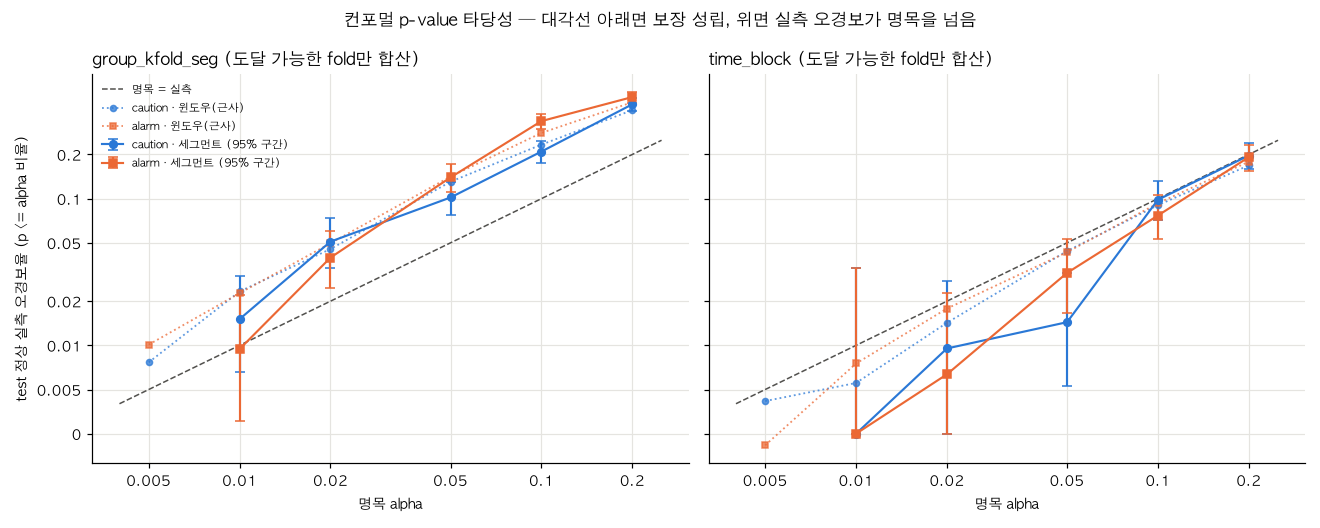

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
STYLE = {("caution", "segment"): ("#2a78d6", "-o"), ("alarm", "segment"): ("#eb6834", "-s"),
         ("caution", "window"): ("#2a78d6", ":o"), ("alarm", "window"): ("#eb6834", ":s")}
LV_KO = {"segment": "세그먼트", "window": "윈도우(근사)"}
for ax, sp in zip(axes, SPLITS):
    ax.plot([0.004, 0.25], [0.004, 0.25], color="#52514e", lw=1, ls="--", label="명목 = 실측")
    for (sc, lv), (color, fmt) in STYLE.items():
        t = VAL[(VAL.split == sp) & (VAL.score == sc) & (VAL.level == lv) & (VAL.fold == "pooled") & VAL.attainable]
        y = t.rate.to_numpy(float)
        floor = 0.0025                                   # 로그축에서 실측 0을 그리기 위한 바닥
        yp = np.where(y > 0, y, floor)
        if lv == "segment":
            lo = np.clip(t.ci_lo.to_numpy(float), floor, None); hi = t.ci_hi.to_numpy(float)
            ax.errorbar(t.alpha, yp, yerr=[np.clip(yp - lo, 0, None), np.clip(hi - yp, 0, None)], fmt=fmt, color=color,
                        ms=5, lw=1.4, capsize=3, label=f"{sc} · {LV_KO[lv]} (95% 구간)")
        else:
            ax.plot(t.alpha, yp, fmt, color=color, ms=4, lw=1.2, alpha=0.75, label=f"{sc} · {LV_KO[lv]}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(ALPHAS); ax.set_xticklabels([f"{a:g}" for a in ALPHAS]); ax.minorticks_off()
    ax.set_yticks([0.0025, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]); ax.set_yticklabels(["0", "0.005", "0.01", "0.02", "0.05", "0.1", "0.2"])
    ax.set_xlabel("명목 alpha"); ax.set_title(f"{sp} (도달 가능한 fold만 합산)", loc="left")
axes[0].set_ylabel("test 정상 실측 오경보율 (p <= alpha 비율)")
axes[0].legend(fontsize=7, frameon=False, loc="upper left")
fig.suptitle("컨포멀 p-value 타당성 — 대각선 아래면 보장 성립, 위면 실측 오경보가 명목을 넘음", fontsize=11)
paths.save_fig(FIG, "validity_curve.png")
display(Image(filename=str(FIG / "validity_curve.png")))

### D. 운영 alpha에서의 성능 — 주의 0.04 · 경보 0.01

- 방법: fold마다 `thr = conformal_threshold(calibration 세그먼트 점수, alpha)`를 정하고 test 윈도우에 `evaluate.segment_alarms(any)`를 적용한다(1절 assert로 `p_seg <= alpha`와 같은 판정). 두 alpha × 두 점수 = 4조합이고, 사전 지정 운영점은 **주의 = s_caution · 0.04**, **경보 = s_alarm · 0.01**이다(나머지 2개는 참고).
- 집계는 31과 같은 규약: gkf는 fold별 혼동행렬을 `pool_confusion`으로 합산(`fold = pooled`), time_block은 블록별로 낸 뒤 블록 평균(`block_mean`). 도달 불가 fold는 임계가 무한대라 **경보가 한 번도 울리지 않는다**(fp 0·tp 0). 이것이 그 규칙의 실제 동작이므로 `block_mean`에는 그대로 넣고, 도달 가능한 블록만 평균한 `block_mean_attainable`을 따로 둔다.
- 지연은 `evaluate`의 정의(첫 초과 윈도우 `t_start + win_s − 0.1`), 시간당 오경보 = `fpr_segment × 413.35`(판정 가능 정상 세그먼트/시간, `reports/32_operating_point_CHS.md` 1절).

In [8]:
def op_fold(sp, k, sc, a):
    f = FOLDS[(sp, k)]
    thr = cf.conformal_threshold(f["cal_seg"][sc], a)
    t = WIN[(WIN.split == sp) & (WIN.fold == k) & (WIN.part == "test")]
    nrm, otl = t[t.label == 0], t[t.label == 1]
    an = ev.segment_alarms(nrm[f"s_{sc}"], nrm.seg_uid, nrm.t_start, thr, win_s=1.0)
    ao = ev.segment_alarms(otl[f"s_{sc}"], otl.seg_uid, otl.t_start, thr, win_s=1.0)
    return ev.segment_confusion(an, ao), an, ao, thr

ROLE = {("caution", ALPHA_CAUTION): "주의", ("alarm", ALPHA_ALARM): "경보"}
KEEP = ["fp", "n_normal", "fpr_segment", "tp", "fn", "n_outlier", "recall", "f1"]
rows, ALARM_SETS = [], {}
for sc in SCORES:
    for a in OP_ALPHAS:
        role = ROLE.get((sc, a), "참고")
        for sp in SPLITS:
            per, conf, delays = [], [], []
            for (s2, k), f in FOLDS.items():
                if s2 != sp:
                    continue
                c, an, ao, thr = op_fold(sp, k, sc, a)
                ALARM_SETS[(sc, a, sp, k)] = set(an.loc[an.alarm, "seg_uid"]) | set(ao.loc[ao.alarm, "seg_uid"])
                d = ao.loc[ao.alarm, "delay_in_window_s"]
                per.append({"fold": str(k), "attainable": cf.is_attainable(f["n_cal_seg"], a), "thr": thr, **{key: c[key] for key in KEEP},
                            "delay_median_s": float(d.median()) if len(d) else np.nan})
                conf.append(c); delays.append(d)
            per = pd.DataFrame(per)
            n_att = int(per.attainable.sum())
            if sp == "group_kfold_seg":
                c = ev.pool_confusion(conf); d = pd.concat(delays)
                agg = [{"fold": "pooled", "attainable": n_att > 0, "thr": np.nan, **{key: c[key] for key in KEEP},
                        "delay_median_s": float(d.median()) if len(d) else np.nan}]
            else:
                agg = [{"fold": "block_mean", "attainable": n_att > 0, "thr": np.nan, **per[KEEP + ["delay_median_s"]].mean().to_dict()}]
                pa = per[per.attainable]
                agg.append({"fold": "block_mean_attainable", "attainable": n_att > 0, "thr": np.nan,
                            **(pa[KEEP + ["delay_median_s"]].mean().to_dict() if len(pa) else {key: np.nan for key in KEEP + ["delay_median_s"]})})
            for r in pd.concat([per, pd.DataFrame(agg)], ignore_index=True).to_dict("records"):
                rows.append({"role": role, "score": sc, "alpha": a, "split": sp, **r, "n_folds": len(per), "n_folds_attainable": n_att})
OP = pd.DataFrame(rows)
OP["fp_per_hour"] = OP.fpr_segment * SEG_PER_HOUR
OP["felt_delay_median_s"] = OP.delay_median_s + ev.BURST_GAP_S
OP_COLS = ["role", "score", "alpha", "split", "fold", "attainable", "n_folds", "n_folds_attainable", "thr"] + KEEP \
          + ["delay_median_s", "felt_delay_median_s", "fp_per_hour"]
OP = OP[OP_COLS]
OP.to_csv(RES / "operating_alpha.csv", index=False)
show = ["role", "score", "alpha", "split", "fold", "n_folds_attainable", "fp", "n_normal", "fpr_segment", "tp", "fn", "n_outlier", "recall", "f1", "delay_median_s", "fp_per_hour"]
print("[집계 행] gkf = 5 fold 합산, time_block = 블록 평균(전체 / 도달 가능 블록만)")
print(OP[OP.fold.isin(["pooled", "block_mean", "block_mean_attainable"])][show].round(4).to_string(index=False))
print("\n[사전 지정 운영점의 fold별 행]")
print(OP[(OP.role != "참고") & ~OP.fold.isin(["pooled", "block_mean", "block_mean_attainable"])][["role", "split", "fold", "attainable", "thr"] + KEEP + ["delay_median_s"]].round(4).to_string(index=False))
# 2단계 구조 점검: 경보(s_alarm, 0.01)가 울린 세그먼트가 주의(s_caution, 0.04)에도 포함되는가 (점수·alpha가 달라 자동 보장은 아님)
n_viol = sum(len(ALARM_SETS[("alarm", ALPHA_ALARM, sp, k)] - ALARM_SETS[("caution", ALPHA_CAUTION, sp, k)]) for (sp, k) in FOLDS)
print(f"\n경보는 울렸는데 주의는 울리지 않은 세그먼트 수(9분할 합): {n_viol}")

[집계 행] gkf = 5 fold 합산, time_block = 블록 평균(전체 / 도달 가능 블록만)
role   score  alpha           split                  fold  n_folds_attainable    fp  n_normal  fpr_segment    tp    fn  n_outlier  recall     f1  delay_median_s  fp_per_hour
  주의 caution   0.04 group_kfold_seg                pooled                   5 46.00    530.00       0.0868 17.00  0.00       17.0    1.00 0.4250             0.9      35.8757
  주의 caution   0.04      time_block            block_mean                   4  1.50    104.25       0.0145 17.00  0.00       17.0    1.00 0.9587             0.9       6.0019
  주의 caution   0.04      time_block block_mean_attainable                   4  1.50    104.25       0.0145 17.00  0.00       17.0    1.00 0.9587             0.9       6.0019
  참고 caution   0.01 group_kfold_seg                pooled                   5  8.00    530.00       0.0151 17.00  0.00       17.0    1.00 0.8095             0.9       6.2392
  참고 caution   0.01      time_block            block_mean              

### E. calibration을 떼어 낸 비용 — 23 원 규칙(z > 1) 대비

- 방법: proper-train(train의 75%)으로 적합한 모델에 23의 원 규칙(`z > 1`, 즉 자기 학습 정상 q99)을 그대로 적용해 `fpr_segment`와 탐지된 이상 세그먼트 수를 구하고, 23이 공개한 `metrics.csv`(전체 train 적합, MCD 3시드 평균)의 `ridge_diff`·`ridge&mcd` 행과 비교한다. 탐지 수는 `cv_scores.csv`의 seed 0 행에서 읽는다. 컨포멀 계층과 무관하게 **학습 정상이 25% 줄어든 효과만** 분리한다.
- 재현 점검: 같은 코드로 전체 train(seed 0)에 적합했을 때 23의 seed 0 `fpr_segment`가 재현되는지도 함께 적는다(`fpr_segment_full_repro`).

In [9]:
M23 = pd.read_csv(REF23 / "metrics.csv")
CV23 = pd.read_csv(REF23 / "cv_scores.csv")
CV23 = CV23[CV23.seed == MCD_SEED]
RULE_OF = {"ridge_diff": "caution", "ridge&mcd": "alarm"}            # z > 1 규칙: s_caution = z_ridge, s_alarm = min(z_ridge, z_mcd)

def rule_stats(t, sc):
    """z > 1 규칙의 정상 세그먼트 오경보율과 탐지된 이상 세그먼트 수."""
    nrm, otl = t[t.label == 0], t[t.label == 1]
    fpr = ev.fpr_segment(nrm[f"s_{sc}"], nrm.seg_uid, 1.0)
    det = ev.detection_delay_s(otl[f"s_{sc}"], otl.seg_uid, otl.t_start, 1.0, win_s=1.0)
    return fpr, int(det.detected.sum()), len(det)

rows = []
for split_name, fold, train, test in bj.iter_splits(WINS):
    # 전체 train 적합(23과 같은 절차, seed 0) — 재현 점검용
    uids = train.seg_uid.drop_duplicates().tolist()
    ridge = RidgeVAR(lookback=LOOKBACK, win=int(FS)).fit([DIFF[u] for u in uids])
    mcd = ej.RobustMCD(bj.AMP_COLS, seed=MCD_SEED).fit(DIFF_AMP.loc[train.index])
    zr = ridge.score(DIFF, test) / ev.threshold_from_normal(ridge.score(DIFF, train))
    zm = mcd.score(DIFF_AMP.loc[test.index]) / ev.threshold_from_normal(mcd.score(DIFF_AMP.loc[train.index]))
    full = test[["seg_uid", "t_start", "label"]].reset_index(drop=True).assign(s_caution=zr, s_alarm=np.minimum(zr, zm))
    prop_t = WIN[(WIN.split == split_name) & (WIN.fold == fold) & (WIN.part == "test")]
    f = FOLDS[(split_name, fold)]
    for rule, sc in RULE_OF.items():
        fpr_p, det_p, n_o = rule_stats(prop_t, sc)
        fpr_f, det_f, _ = rule_stats(full, sc)
        m = M23[(M23.model == rule) & (M23.split == split_name) & (M23.fold == str(fold))].iloc[0]
        c = CV23[(CV23.model == rule) & (CV23.split == split_name) & (CV23.fold == fold)].iloc[0]
        rows.append({"split": split_name, "fold": str(fold), "rule": rule, "n_train_seg_full": f["n_train_seg"], "n_train_seg_proper": f["n_proper_seg"],
                     "n_out_seg": n_o, "fpr_segment_proper": fpr_p, "n_detected_proper": det_p,
                     "fpr_segment_23_metrics": float(m.fpr_segment), "fpr_segment_23_seed0": float(c.fpr_segment), "n_detected_23_seed0": int(c.n_detected),
                     "fpr_segment_full_repro": fpr_f, "n_detected_full_repro": det_f})
COST = pd.DataFrame(rows)
num = [c for c in COST.columns if c not in ("split", "fold", "rule")]
mean = COST.groupby(["split", "rule"], sort=False)[num].mean().reset_index().assign(fold="mean")
COST = pd.concat([COST, mean], ignore_index=True)[["split", "fold", "rule"] + num]
COST["delta_fpr_vs_23_metrics"] = COST.fpr_segment_proper - COST.fpr_segment_23_metrics
COST["delta_detected_vs_23_seed0"] = COST.n_detected_proper - COST.n_detected_23_seed0
COST.to_csv(RES / "holdout_cost.csv", index=False)
# 23 metrics.csv의 mean 행과 여기서 다시 계산한 fold 평균이 같은지 확인
for r in COST[COST.fold == "mean"].itertuples():
    pub = float(M23[(M23.model == r.rule) & (M23.split == r.split) & (M23.fold == "mean")].fpr_segment.iloc[0])
    assert abs(pub - r.fpr_segment_23_metrics) < 1e-12
per = COST[COST.fold != "mean"]
print(f"전체 train 재적합(seed 0)과 23 cv_scores seed 0의 fpr_segment 최대 절대차: {float((per.fpr_segment_full_repro - per.fpr_segment_23_seed0).abs().max()):.2e}"
      f" | 탐지 수 불일치 fold: {int((per.n_detected_full_repro != per.n_detected_23_seed0).sum())}")
show = ["split", "fold", "rule", "n_train_seg_full", "n_train_seg_proper", "fpr_segment_proper", "fpr_segment_23_metrics", "delta_fpr_vs_23_metrics",
        "n_detected_proper", "n_detected_23_seed0", "n_out_seg"]
print(COST[show].round(4).to_string(index=False))

전체 train 재적합(seed 0)과 23 cv_scores seed 0의 fpr_segment 최대 절대차: 9.02e-17 | 탐지 수 불일치 fold: 0
          split fold       rule  n_train_seg_full  n_train_seg_proper  fpr_segment_proper  fpr_segment_23_metrics  delta_fpr_vs_23_metrics  n_detected_proper  n_detected_23_seed0  n_out_seg
group_kfold_seg    0 ridge_diff             421.0              316.00              0.0459                  0.0459                   0.0000                5.0                  5.0        5.0
group_kfold_seg    0  ridge&mcd             421.0              316.00              0.0092                  0.0000                   0.0092                5.0                  5.0        5.0
group_kfold_seg    1 ridge_diff             426.0              319.00              0.0288                  0.0288                   0.0000                4.0                  4.0        4.0
group_kfold_seg    1  ridge&mcd             426.0              319.00              0.0000                  0.0000                   0.0000           

### F. 운전 상태별 타당성

- 방법: 세그먼트 단위 실측 오경보율을 alpha 0.01·0.04에서 고부하(0)·저부하(1)로 나눠 본다. 컨포멀 보장은 **주변(marginal)** 보장이라 상태별로 alpha가 지켜진다는 보장은 없다 — 여기서는 조정 없이 보고만 한다. 집계는 도달 가능한 fold만 합산(`pooled`)하고 time_block은 블록 평균도 함께 낸다(해당 상태의 정상 세그먼트가 있는 도달 가능 블록만).

In [10]:
rows = []
for sp in SPLITS:
    for sc in SCORES:
        for a in OP_ALPHAS:
            for st in (0, 1):
                per = []
                for (s2, k), f in FOLDS.items():
                    if s2 != sp:
                        continue
                    t = SEG[(SEG.split == sp) & (SEG.fold == k) & (SEG.label == 0) & (SEG.state == st)]
                    per.append({"attainable": cf.is_attainable(f["n_cal_seg"], a), "n": len(t), "k": int(cf.reject(t[f"p_seg_{sc}"], a).sum())})
                per = pd.DataFrame(per)
                pa = per[per.attainable]
                n, k = int(pa.n.sum()), int(pa.k.sum())
                lo, hi = cf.binomial_interval(k, n)
                pb = pa[pa.n > 0]
                rows.append({"split": sp, "score": sc, "alpha": a, "state": st, "state_name": STATE_KO[st], "n_folds": len(per),
                             "n_folds_attainable": len(pa), "n_normal": n, "n_reject": k, "rate_pooled": k / n if n else np.nan,
                             "ci_lo": lo, "ci_hi": hi, "alpha_in_ci": bool(lo <= a <= hi) if n else None,
                             "rate_fold_mean": float((pb.k / pb.n).mean()) if len(pb) else np.nan})
BYSTATE = pd.DataFrame(rows)
BYSTATE.to_csv(RES / "validity_by_state.csv", index=False)
print(BYSTATE.drop(columns=["state"]).round(4).to_string(index=False))
print("\ncalibration 세그먼트의 상태 구성(고부하 비율)과 test 정상의 상태 구성")
rows = []
for (sp, k), f in FOLDS.items():
    c = WIN[(WIN.split == sp) & (WIN.fold == k) & (WIN.part == "cal")].groupby("seg_uid").state.first()
    t = SEG[(SEG.split == sp) & (SEG.fold == k) & (SEG.label == 0)].state
    rows.append({"split": sp, "fold": k, "cal_high_share": float((c == 0).mean()), "test_high_share": float((t == 0).mean())})
print(pd.DataFrame(rows).round(3).to_string(index=False))

          split   score  alpha state_name  n_folds  n_folds_attainable  n_normal  n_reject  rate_pooled  ci_lo  ci_hi  alpha_in_ci  rate_fold_mean
group_kfold_seg caution   0.04        고부하        5                   5       226        27       0.1195 0.0802 0.1690        False          0.1170
group_kfold_seg caution   0.04        저부하        5                   5       304        19       0.0625 0.0380 0.0959         True          0.0634
group_kfold_seg caution   0.01        고부하        5                   5       226         6       0.0265 0.0098 0.0569         True          0.0269
group_kfold_seg caution   0.01        저부하        5                   5       304         2       0.0066 0.0008 0.0236         True          0.0065
group_kfold_seg   alarm   0.04        고부하        5                   5       226        44       0.1947 0.1452 0.2524        False          0.1958
group_kfold_seg   alarm   0.04        저부하        5                   5       304         4       0.0132 0.0036 0.0333 

### G. 정상·이상 세그먼트 p-value 분포 (경보 점수)

- 방법: 경보 점수 `s_alarm`의 세그먼트 p-value 누적분포를 정상·이상으로 나눠 로그축에 그린다. 정상 곡선이 균등분포 곡선(y = p, 로그축이라 휘어 보인다) 위로 올라가면 그 구간에서 실측 오경보가 명목을 넘는다는 뜻이다. gkf는 5 fold를 합쳐(이상 17개가 한 번씩), time_block은 블록별로 그린다. 세로 점선은 운영 alpha 0.01·0.04.

saved figures/36_conformal_pvalue_CHS/pvalue_distribution.png


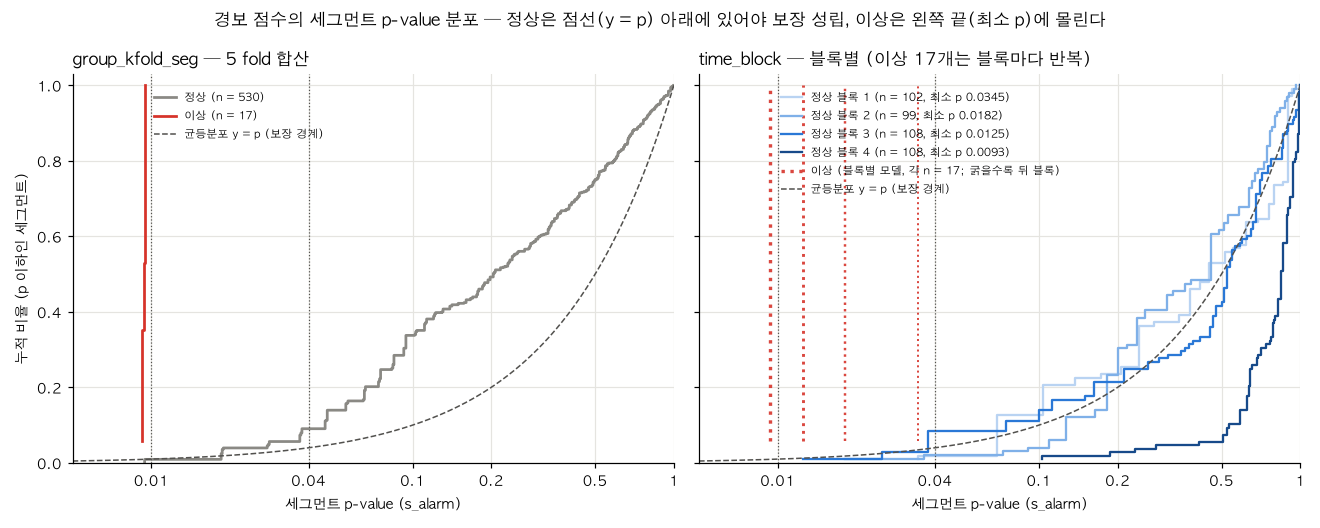

In [11]:
def ecdf(p):
    x = np.sort(np.asarray(p, dtype=float))
    return x, np.arange(1, len(x) + 1) / len(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
ax = axes[0]
t = SEG[SEG.split == "group_kfold_seg"]
for lab, color, name in ((0, "#8a8984", "정상"), (1, "#d6332a", "이상")):
    x, y = ecdf(t.loc[t.label == lab, "p_seg_alarm"])
    ax.step(x, y, where="post", color=color, lw=1.8, label=f"{name} (n = {len(x)})")
ax.set_title("group_kfold_seg — 5 fold 합산", loc="left")
ax = axes[1]
BLOCK_COL = {1: "#b9d3f2", 2: "#7fb0e8", 3: "#2a78d6", 4: "#174a8a"}
t = SEG[SEG.split == "time_block"]
for k in (1, 2, 3, 4):
    g = t[t.fold == k]
    x, y = ecdf(g.loc[g.label == 0, "p_seg_alarm"])
    ax.step(x, y, where="post", color=BLOCK_COL[k], lw=1.5, label=f"정상 블록 {k} (n = {len(x)}, 최소 p {g.min_p_seg.iloc[0]:.4f})")
    x, y = ecdf(g.loc[g.label == 1, "p_seg_alarm"])
    ax.step(x, y, where="post", color="#d6332a", lw=1.0 + 0.3 * k, ls=":", alpha=0.9, label="이상 (블록별 모델, 각 n = 17; 굵을수록 뒤 블록)" if k == 4 else None)
ax.set_title("time_block — 블록별 (이상 17개는 블록마다 반복)", loc="left")
for ax in axes:
    xs = np.logspace(np.log10(0.005), 0, 200)
    ax.plot(xs, xs, color="#52514e", lw=1, ls="--", label="균등분포 y = p (보장 경계)")
    for a in OP_ALPHAS:
        ax.axvline(a, color="#52514e", lw=0.8, ls=":")
    ax.set_xscale("log"); ax.set_xlim(0.005, 1.0); ax.set_ylim(0, 1.03)
    ax.set_xticks([0.01, 0.04, 0.1, 0.2, 0.5, 1.0]); ax.set_xticklabels(["0.01", "0.04", "0.1", "0.2", "0.5", "1"]); ax.minorticks_off()
    ax.set_xlabel("세그먼트 p-value (s_alarm)")
    ax.legend(fontsize=7, frameon=False, loc="upper left", bbox_to_anchor=(0.12, 0.98))
axes[0].set_ylabel("누적 비율 (p 이하인 세그먼트)")
fig.suptitle("경보 점수의 세그먼트 p-value 분포 — 정상은 점선(y = p) 아래에 있어야 보장 성립, 이상은 왼쪽 끝(최소 p)에 몰린다", fontsize=11)
paths.save_fig(FIG, "pvalue_distribution.png")
display(Image(filename=str(FIG / "pvalue_distribution.png")))

### H. 사후 추가 분석 — calibration을 무작위로 뽑으면 보장이 회복되는가

- **이 절은 A~G 결과를 본 뒤에 추가했다. 사전 고정 설계가 아니며, 운영점·결론 수치(A~G)는 바꾸지 않는다.** C절에서 gkf의 실측 오경보율이 명목 alpha의 2~3배로 나온 원인이 "시간상 가장 최근 25%를 calibration으로 둔 것"인지 확인하는 것이 목적이다.
- 방법: 같은 9분할·같은 모델·같은 `CAL_FRAC` 0.25에서 calibration 세그먼트만 무작위로 뽑는다(`conformal.random_split`, 시드 0~4의 5회 반복, 개수 규칙 동일). 시간순 분할(`time_latest`)도 같은 함수로 다시 계산해 1절의 p-value와 일치하는지 assert한다. 세그먼트 단위 실측 정상 오경보율을 alpha 격자에서 세고, 도달 가능한 fold만 합산한다. 무작위 분할은 반복별 합산 비율의 평균·최소·최대와, 반복별 Clopper–Pearson 95% 구간이 명목 alpha를 포함한 반복 수를 낸다.
- 원인 확인용으로 calibration·proper-train·test 정상의 고부하 세그먼트 비율을 분할 방식별로 함께 저장한다.
- 해석 주의: time_block에서 무작위로 뽑은 calibration은 여전히 test보다 과거 구간에서만 나온다. gkf는 train과 test가 시간상 섞여 있어 무작위 calibration이 test와 교환 가능에 가깝다. 반복 5회는 같은 test 세그먼트를 다시 쓰므로 반복 간 독립이 아니다.


사후 분석 적합 54회 완료 (18초) | time_latest 재계산 == 1절 p-value: True

고부하 세그먼트 비율 (fold·반복 평균)
                             high_load_cal  high_load_proper  high_load_test_normal
split           cal_rule                                                           
group_kfold_seg time_latest         0.1716            0.5113                 0.4264
                random              0.4313            0.4248                 0.4264
time_block      time_latest         0.4928            0.4906                 0.4127
                random              0.4867            0.4927                 0.4127

[group_kfold_seg] 세그먼트 단위 실측 정상 오경보율: 시간순(time_latest) vs 무작위(random, 5회 평균 [최소~최대], 구간이 alpha를 포함한 반복 수)
  주의 s_caution = z_ridge
       time_latest  random_mean  random_min  random_max random_reps_in_ci  folds
alpha                                                                           
0.01        0.0151       0.0117      0.0057      0.0189               5/5      5
0.02        0.0509       0.0249    

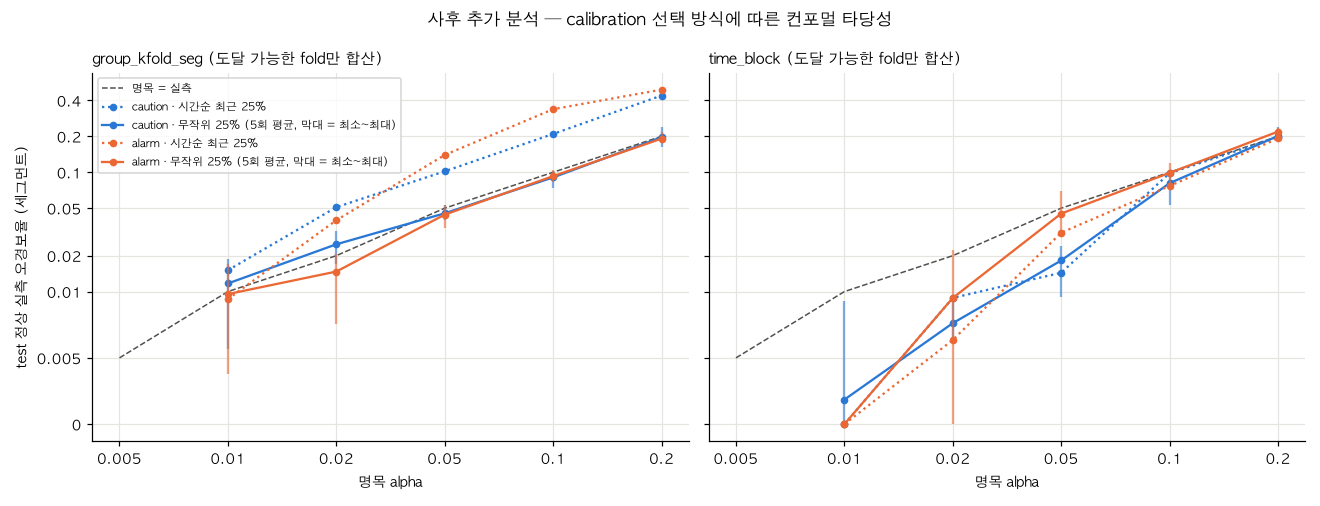

In [12]:
# ---- 사후 추가 분석: A~G 결과를 본 뒤 추가했다. 사전 고정 설계가 아니다. ----
N_REP = 5                                            # 무작위 분할 반복 수 (시드 0~4)


def seg_pvalues(train, test, prop_uids, cal_uids):
    """proper-train 적합 → calibration·test 세그먼트 최댓값 → test 세그먼트 p-value (점수별 DataFrame)."""
    prop, cal = train[train.seg_uid.isin(prop_uids)], train[train.seg_uid.isin(cal_uids)]
    ridge = RidgeVAR(lookback=LOOKBACK, win=int(FS)).fit([DIFF[u] for u in prop_uids])
    mcd = ej.RobustMCD(bj.AMP_COLS, seed=MCD_SEED).fit(DIFF_AMP.loc[prop.index])
    r_thr = ev.threshold_from_normal(ridge.score(DIFF, prop))
    m_thr = ev.threshold_from_normal(mcd.score(DIFF_AMP.loc[prop.index]))

    def smax(frame):
        zr = ridge.score(DIFF, frame) / r_thr
        zm = mcd.score(DIFF_AMP.loc[frame.index]) / m_thr
        return {"caution": cf.segment_max(zr, frame.seg_uid), "alarm": cf.segment_max(np.minimum(zr, zm), frame.seg_uid)}

    c, t = smax(cal), smax(test)
    return {sc: pd.DataFrame({"seg_uid": t[sc].index, "label": ATTR.label.reindex(t[sc].index).to_numpy(),
                              "p": cf.p_values(c[sc].to_numpy(), t[sc].to_numpy())}) for sc in SCORES}


hi_share = lambda uids: float((ATTR.state.reindex(list(uids)) == 0).mean())      # 고부하 세그먼트 비율
rows, share = [], []
t_h = time.time()
for split_name, fold, train, test in bj.iter_splits(WINS):
    uids = train.seg_uid.drop_duplicates().tolist()
    test_norm = test.loc[test.label == 0, "seg_uid"].drop_duplicates().tolist()
    variants = [("time_latest", 0, cf.time_ordered_split(uids, CAL_FRAC))]
    variants += [("random", r, cf.random_split(uids, CAL_FRAC, seed=r)) for r in range(N_REP)]
    for rule, rep, (pu, cu) in variants:
        assert not (set(pu) & set(cu)) and set(pu) | set(cu) == set(uids) and len(cu) == FOLDS[(split_name, fold)]["n_cal_seg"]
        res = seg_pvalues(train, test, pu, cu)
        if rule == "time_latest":                                                 # 1절 결과와 같은지 확인
            ref = SEG[(SEG.split == split_name) & (SEG.fold == fold)].set_index("seg_uid")
            for sc in SCORES:
                assert np.allclose(res[sc].p.to_numpy(), ref[f"p_seg_{sc}"].reindex(res[sc].seg_uid).to_numpy(), atol=1e-12)
        share.append({"split": split_name, "fold": fold, "cal_rule": rule, "rep": rep, "n_cal_seg": len(cu),
                      "high_load_cal": hi_share(cu), "high_load_proper": hi_share(pu), "high_load_test_normal": hi_share(test_norm)})
        for sc in SCORES:
            d = res[sc]; nrm, otl = d[d.label == 0], d[d.label == 1]
            for a in ALL_ALPHAS:
                att = cf.is_attainable(len(cu), a)
                rows.append({"split": split_name, "fold": fold, "cal_rule": rule, "rep": rep, "score": sc, "alpha": a, "attainable": att,
                             "n_normal": len(nrm), "n_reject": int(cf.reject(nrm.p, a).sum()) if att else 0,
                             "n_out": len(otl), "n_out_reject": int(cf.reject(otl.p, a).sum()) if att else 0})
PH = pd.DataFrame(rows)
SHARE = pd.DataFrame(share)
SHARE.to_csv(RES / "posthoc_calibration_state_share.csv", index=False)
print(f"사후 분석 적합 {len(share)}회 완료 ({time.time() - t_h:.0f}초) | time_latest 재계산 == 1절 p-value: True")

# 반복별로 도달 가능한 fold만 합산 → 반복 간 평균·범위
agg = []
for (sp, rule, rep, sc, a), g in PH[PH.attainable].groupby(["split", "cal_rule", "rep", "score", "alpha"], sort=False):
    k, n = int(g.n_reject.sum()), int(g.n_normal.sum())
    lo, hi = cf.binomial_interval(k, n)
    agg.append({"split": sp, "cal_rule": rule, "rep": rep, "score": sc, "alpha": a, "n_folds_attainable": len(g), "n_normal": n,
                "n_reject": k, "rate": k / n, "ci_lo": lo, "ci_hi": hi, "alpha_in_ci": bool(lo <= a <= hi),
                "n_out": int(g.n_out.sum()), "n_out_reject": int(g.n_out_reject.sum())})
PHA = pd.DataFrame(agg)
PHS = (PHA.groupby(["split", "score", "alpha", "cal_rule"], sort=False)
       .agg(n_reps=("rep", "size"), n_folds_attainable=("n_folds_attainable", "first"), n_normal=("n_normal", "first"),
            rate_mean=("rate", "mean"), rate_min=("rate", "min"), rate_max=("rate", "max"),
            n_reps_alpha_in_ci=("alpha_in_ci", "sum"), out_reject_min=("n_out_reject", "min"), n_out=("n_out", "first")).reset_index())
PHS["rate_over_alpha"] = PHS.rate_mean / PHS.alpha
PHS.to_csv(RES / "posthoc_random_calibration.csv", index=False)

sh = SHARE.groupby(["split", "cal_rule"], sort=False)[["high_load_cal", "high_load_proper", "high_load_test_normal"]].mean()
print("\n고부하 세그먼트 비율 (fold·반복 평균)")
print(sh.round(4).to_string())
for sp in SPLITS:
    print(f"\n[{sp}] 세그먼트 단위 실측 정상 오경보율: 시간순(time_latest) vs 무작위(random, 5회 평균 [최소~최대], 구간이 alpha를 포함한 반복 수)")
    t = PHS[(PHS.split == sp) & PHS.alpha.isin(ALPHAS)]
    for sc in SCORES:
        w = t[t.score == sc].pivot(index="alpha", columns="cal_rule", values=["rate_mean", "rate_min", "rate_max", "n_reps_alpha_in_ci", "n_folds_attainable"])
        out = pd.DataFrame({"time_latest": w[("rate_mean", "time_latest")].round(4),
                            "random_mean": w[("rate_mean", "random")].round(4),
                            "random_min": w[("rate_min", "random")].round(4), "random_max": w[("rate_max", "random")].round(4),
                            "random_reps_in_ci": w[("n_reps_alpha_in_ci", "random")].astype("Int64").astype(str) + f"/{N_REP}",
                            "folds": w[("n_folds_attainable", "random")].astype("Int64")})
        print(f"  {SCORE_KO[sc]}"); print(out.to_string())
op = PHS[((PHS.score == "caution") & np.isclose(PHS.alpha, ALPHA_CAUTION)) | ((PHS.score == "alarm") & np.isclose(PHS.alpha, ALPHA_ALARM))]
print("\n운영 alpha에서 (이상 탐지 수는 반복 중 최솟값 / 도달 가능 fold의 이상 세그먼트 수)")
print(op[["split", "score", "alpha", "cal_rule", "n_folds_attainable", "n_normal", "rate_mean", "rate_min", "rate_max", "out_reject_min", "n_out"]].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, sp in zip(axes, SPLITS):
    xs = np.arange(len(ALPHAS))
    ax.plot(xs, ALPHAS, "--", color="#52514e", lw=1, label="명목 = 실측")
    for sc, color in (("caution", "#2a78d6"), ("alarm", "#eb6834")):
        for rule, ls in (("time_latest", ":"), ("random", "-")):
            t = PHS[(PHS.split == sp) & (PHS.score == sc) & (PHS.cal_rule == rule)].set_index("alpha").reindex(ALPHAS)
            ax.plot(xs, t.rate_mean, ls, marker="o", ms=4, color=color, label=f"{sc} · {'시간순 최근 25%' if rule == 'time_latest' else '무작위 25% (5회 평균, 막대 = 최소~최대)'}")
            if rule == "random":
                ax.vlines(xs, t.rate_min, t.rate_max, color=color, lw=1.5, alpha=.6)
    ax.set_xticks(xs); ax.set_xticklabels([f"{a:g}" for a in ALPHAS]); ax.set_yscale("symlog", linthresh=0.01)
    ax.set_yticks([0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4]); ax.set_yticklabels(["0", "0.005", "0.01", "0.02", "0.05", "0.1", "0.2", "0.4"])
    ax.set_xlabel("명목 alpha"); ax.set_title(f"{sp} (도달 가능한 fold만 합산)", loc="left", fontsize=10)
axes[0].set_ylabel("test 정상 실측 오경보율 (세그먼트)"); axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("사후 추가 분석 — calibration 선택 방식에 따른 컨포멀 타당성", fontsize=11)
paths.save_fig(FIG, "posthoc_validity_random.png")
display(Image(str(FIG / "posthoc_validity_random.png")))


### 결론

이상은 다른 날짜의 이벤트 1건(판정 가능 17세그먼트)이고 정상은 77분 하루치다. 아래 탐지 수치는 이 이벤트의 기술이며, p-value는 "정상이라는 가정 아래 이만큼 극단적일 확률의 상한"이지 이상일 확률이 아니다.

| 절 | 결과 |
|---|---|
| A | calibration 세그먼트는 gkf 105~107개(최소 p 0.0093~0.0094), time_block 28 / 54 / 79 / 106개(최소 p 0.0345 / 0.0182 / 0.0125 / 0.0093). alpha 0.005는 9분할 전부, **0.01은 time_block 1~3**, 0.02는 time_block 1에서 도달 불가 |
| B | 이상 17세그먼트는 9분할 모두에서 두 점수의 p가 **최소값 1/(n+1)** 에 붙는다(이상 세그먼트 점수 최소 4.40 대 test 정상 최대 1.33, `s_alarm` gkf). gkf: p <= 0.04·0.01 모두 17/17. time_block: p <= 0.04는 블록 1~4 모두 17/17, p <= 0.01은 블록 4만 17/17이고 블록 1~3은 0/17(도달 불가) |
| C | **gkf에서는 보장이 깨진다**: 세그먼트 단위 실측 오경보율이 alpha 0.02 이상에서 명목의 약 2~3.4배(`s_caution` 0.02→0.0509, 0.05→0.1019, 0.10→0.2094 / `s_alarm` 0.02→0.0396, 0.05→0.1396, 0.10→0.3377), 10개 조합 중 8개에서 95% 구간 하한이 alpha를 넘는다. alpha 0.01만 구간 안(0.0151, 0.0094). time_block은 합산 기준 명목 이하(`s_caution` 0.05→0.0144, 0.10→0.0983 / `s_alarm` 0.05→0.0312, 0.10→0.0767)지만 블록별로는 0.0000~0.2255(alpha 0.10)로 흩어진다 |
| D | 주의(`s_caution`, 0.04): gkf fp 46/530 = 0.0868(시간당 35.9회, 명목의 2.2배)·17/17·F1 0.4250, time_block 블록 평균 0.0145(시간당 6.0회)·17/17·F1 0.9587. 경보(`s_alarm`, 0.01): gkf fp 5/530 = 0.0094(시간당 3.9회)·17/17·F1 0.8718, time_block은 블록 4에서만 작동(fp 0/108·17/17)하고 블록 1~3은 경보가 울리지 않아 블록 평균 recall 0.25. 지연 중앙값 0.9초 |
| E | 학습 정상을 25% 줄인 비용은 거의 없다: `ridge_diff` fpr_segment gkf 0.0187(23: 0.0206)·time_block 0.0170(0.0170), `ridge&mcd` gkf 0.0018(0.0000, 오경보 1개)·time_block 0.0025(0.0025). 탐지는 모두 17/17 그대로. 전체 train 재적합은 23 seed 0을 재현(최대 차 9e-17) |
| F | 오경보는 고부하에 몰린다: gkf 주의 0.04에서 고부하 0.1195(27/226) 대 저부하 0.0625(19/304), 경보 0.01에서 고부하 0.0221(5/226) 대 저부하 0.0000(0/304) |
| H (사후) | calibration을 무작위 25%로 뽑으면(시드 5회) gkf의 보장이 회복된다: `s_caution` 0.02→0.0249, 0.05→0.0453, 0.10→0.0906, 0.20→0.1966 / `s_alarm` 0.02→0.0147, 0.05→0.0442, 0.10→0.0928, 0.20→0.1913(시간순은 0.0509~0.4925). calibration 고부하 비율은 시간순 0.1716, 무작위 0.4313, test 정상 0.4264. 운영 alpha: 주의 0.04는 0.0868 → 0.0408(반복 0.0302~0.0472), 경보 0.01은 0.0094 → 0.0098, 이상은 모든 반복에서 17/17. time_block은 두 방식이 비슷하다(calibration 고부하 0.4928 대 0.4867) |

- **gkf에서 깨지는 이유**: 사전 고정한 calibration은 "train 정상의 가장 최근 25%"다. gkf는 test 세그먼트가 전 구간에 흩어져 있으므로 calibration은 사실상 수집 마지막 구간이 되고, 그 구간은 고부하 비율이 0.15~0.20으로 test 정상(0.36~0.52)보다 낮다. 마지막 구간이 조용하다는 것은 time_block 4의 실측 오경보율(alpha 0.20에서 0.0370·0.0278)에서도 보인다. 즉 calibration과 test가 교환 가능하지 않다. 설계를 결과에 맞춰 바꾸지 않고 그대로 보고한다. **사후 추가 분석(H)에서 calibration만 무작위로 바꾸자 gkf 실측 오경보율이 명목 수준으로 돌아왔으므로**(alpha 0.05에서 0.1019 → 0.0453), 원인은 모델이나 p-value 계산이 아니라 calibration 구간의 운전 상태 구성이다. H는 결과를 본 뒤 추가한 분석이라 확인용으로만 쓰고 운영점 수치(D)는 사전 설계 값을 유지한다.
- **time_block의 "합산 기준 성립"도 블록 간 상쇄가 섞여 있다**: 블록 1은 alpha 0.10에서 0.2255(`s_caution`)로 넘고 블록 4는 0.0278로 크게 못 미친다. 77분 안에서도 정상 분포가 움직인다.
- **해상도 한계**: calibration 세그먼트 n개로는 p가 1/(n+1) 아래로 내려가지 않는다. 이상 17개가 모두 바닥값이라 p-value로는 이상 사이의 강약을 구분할 수 없고(원 점수는 4.4~92.4로 다르다), alpha 0.01 경보에는 calibration 세그먼트가 99개 이상 필요하다(이 데이터의 수집 속도 413.35 세그먼트/시간으로 약 14분 분량의 판정 가능 정상 세그먼트).
- **경보 ⊆ 주의가 자동으로 지켜지지 않는다**: 두 단계가 점수도 alpha도 달라, 9분할 합쳐 정상 세그먼트 1개(gkf fold 0의 `normal_216`)가 경보만 울리고 주의는 울리지 않았다.
- **23 원 규칙과의 관계**: 컨포멀 계층은 탐지 성능을 높이지 않는다. 경보 alpha 0.01의 임계(z 기준 0.59~0.85)는 23의 AND 규칙(z > 1)보다 느슨해 gkf 오경보율이 0.0094로 23(0.0000~0.0018)보다 높다. 얻는 것은 점수에 "허용 오경보율"이라는 공통 눈금을 붙이는 것과, 그 눈금이 언제 믿을 만한지(calibration이 test와 같은 운전 구성일 때)에 대한 점검 절차다.
- 활용(4번): alpha는 "정상일 때 burst 하나가 잘못 울릴 확률의 상한"으로 현장과 합의하고, calibration 블록은 (1) 99세그먼트 이상, (2) 고부하·저부하 구성이 운전 구성과 비슷하게 잡는다. 실측 오경보율이 alpha의 구간 밖으로 나가면 재보정 신호로 쓴다.

In [13]:
made = sorted(p.name for p in RES.glob("*.csv"))
assert "metrics.csv" not in made, "이 노트북은 metrics.csv를 만들지 않는다"
print("results:", made)
print("figures:", sorted(p.name for p in FIG.glob("*.png")))
print("실행 완료")

results: ['calibration_sizes.csv', 'holdout_cost.csv', 'operating_alpha.csv', 'outlier_pvalues.csv', 'posthoc_calibration_state_share.csv', 'posthoc_random_calibration.csv', 'segment_pvalues.csv', 'validity.csv', 'validity_by_state.csv']
figures: ['posthoc_validity_random.png', 'pvalue_distribution.png', 'validity_curve.png']
실행 완료
